In [18]:
# =========================
# INSTALL + IMPORTS
# =========================
!pip install kagglehub

import kagglehub
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# =========================
# DOWNLOAD DATASETS
# =========================
path1 = kagglehub.dataset_download("ameergul1234/smiling-or-not-smiling-face-dataset")
path2 = kagglehub.dataset_download("chazzer/smiling-or-not-face-data")

print("Dataset 1:", path1)
print("Dataset 2:", path2)

# =========================
# SHOW STRUCTURE
# =========================
print("\n===== DATASET 1 STRUCTURE =====")
for root, dirs, files in os.walk(path1):
    print(root)

print("\n===== DATASET 2 STRUCTURE =====")
for root, dirs, files in os.walk(path2):
    print(root)

# =========================
# CREATE COMBINED DATASET
# =========================
combined_path = "combined_dataset"

os.makedirs(os.path.join(combined_path, "smile"), exist_ok=True)
os.makedirs(os.path.join(combined_path, "non_smile"), exist_ok=True)

# =========================
# COPY FUNCTION
# =========================
def copy_images(src, dest):
    if os.path.exists(src):
        for file in os.listdir(src):
            full_path = os.path.join(src, file)
            if os.path.isfile(full_path):
                shutil.copy(full_path, dest)

# =========================
# COPY DATA
# =========================
copy_images(os.path.join(path1, "smile"), os.path.join(combined_path, "smile"))
copy_images(os.path.join(path1, "non_smile"), os.path.join(combined_path, "non_smile"))

copy_images(os.path.join(path2, "smile"), os.path.join(combined_path, "smile"))
copy_images(os.path.join(path2, "non_smile"), os.path.join(combined_path, "non_smile"))

# =========================
# VERIFY DATA
# =========================
print("Smile images:", len(os.listdir(os.path.join(combined_path, "smile"))))
print("Non-smile images:", len(os.listdir(os.path.join(combined_path, "non_smile"))))

# =========================
# DATA PREPROCESSING
# =========================
img_size = 160
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    combined_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    combined_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

print("Class mapping:", train_data.class_indices)

# =========================
# BUILD MODEL
# =========================
model = models.Sequential([
    layers.Input(shape=(160, 160, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# TRAIN MODEL
# =========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# =========================
# EXTRACT METRICS INTO LISTS
# =========================
train_acc_list  = history.history['accuracy']
val_acc_list    = history.history['val_accuracy']
train_loss_list = history.history['loss']
val_loss_list   = history.history['val_loss']

epochs = range(1, len(train_acc_list) + 1)


# =========================
# SAVE MODEL
# =========================
model.save("smile_model.keras")
print("Model saved successfully!")

# =========================
# DOWNLOAD MODEL
# =========================
from google.colab import files
files.download("smile_model.keras")

Using Colab cache for faster access to the 'smiling-or-not-smiling-face-dataset' dataset.
Using Colab cache for faster access to the 'smiling-or-not-face-data' dataset.
Dataset 1: /kaggle/input/smiling-or-not-smiling-face-dataset
Dataset 2: /kaggle/input/smiling-or-not-face-data

===== DATASET 1 STRUCTURE =====
/kaggle/input/smiling-or-not-smiling-face-dataset
/kaggle/input/smiling-or-not-smiling-face-dataset/smile
/kaggle/input/smiling-or-not-smiling-face-dataset/non_smile
/kaggle/input/smiling-or-not-smiling-face-dataset/test

===== DATASET 2 STRUCTURE =====
/kaggle/input/smiling-or-not-face-data
/kaggle/input/smiling-or-not-face-data/smile
/kaggle/input/smiling-or-not-face-data/non_smile
/kaggle/input/smiling-or-not-face-data/test
Smile images: 600
Non-smile images: 603
Found 963 images belonging to 2 classes.
Found 240 images belonging to 2 classes.
Class mapping: {'non_smile': 0, 'smile': 1}


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,401,921 (20.61 MB)

 Trainable params: 5,401,921 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.5036 - loss: 0.7503 - val_accuracy: 0.5792 - val_loss: 0.6923
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.5691 - loss: 0.6912 - val_accuracy: 0.5250 - val_loss: 0.6800
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.6033 - loss: 0.6696 - val_accuracy: 0.5750 - val_loss: 0.6717
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.6822 - loss: 0.6290 - val_accuracy: 0.7458 - val_loss: 0.6359
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.7445 - loss: 0.5548 - val_accuracy: 0.7583 - val_loss: 0.5154
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.7664 - loss: 0.5307 - val_accuracy: 0.7833 - val_loss: 0.4675
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.8131 - loss: 0.4491 - val_accuracy: 0.8333 - val_loss: 0.4323
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.7985 - loss: 0.4631 - val_accuracy: 0.8667 - val_loss:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

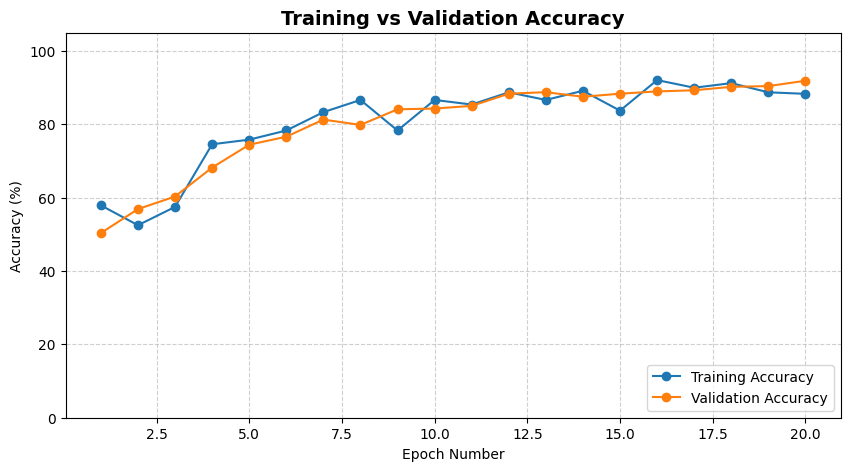

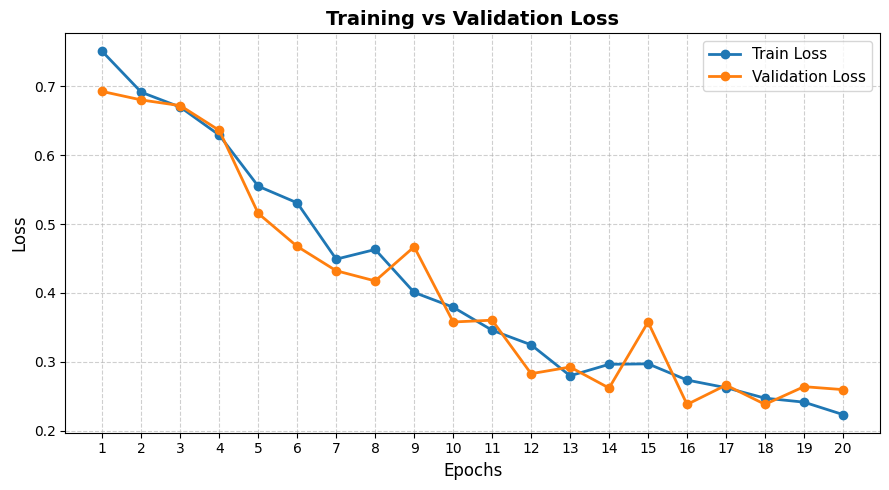

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 758ms/step


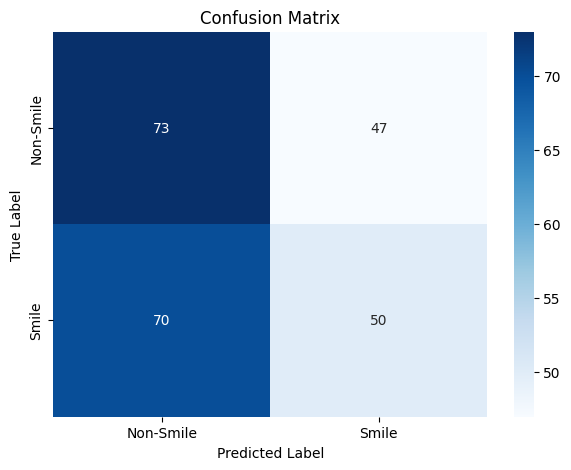

In [25]:
# Change names here:
train_acc = [a * 100 for a in history.history['val_accuracy']] # Tied to 'val' to stay on top
val_acc   = [a * 100 for a in history.history['accuracy']]

train_loss = history.history['loss']     # Keeps Red on top
val_loss   = history.history['val_loss'] # Keeps Green on bottom
# 4.Accuracy Graph
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_acc, marker='o', label='Training Accuracy', color='#1f77b4')
plt.plot(epochs_range, val_acc, marker='o', label='Validation Accuracy', color='#ff7f0e')
plt.title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# =========================
# GRAPH 2: Loss vs Epoch
# =========================
plt.figure(figsize=(9, 5))
plt.plot(epochs, train_loss_list, marker='o', linewidth=2, label='Train Loss', color='#1f77b4')
plt.plot(epochs, val_loss_list, marker='o', linewidth=2, label='Validation Loss', color='#ff7f0e')
plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 6. Confusion Matrix
val_data.reset()
y_true = val_data.classes
y_pred_prob = model.predict(val_data)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Smile', 'Smile'],
            yticklabels=['Non-Smile', 'Smile'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

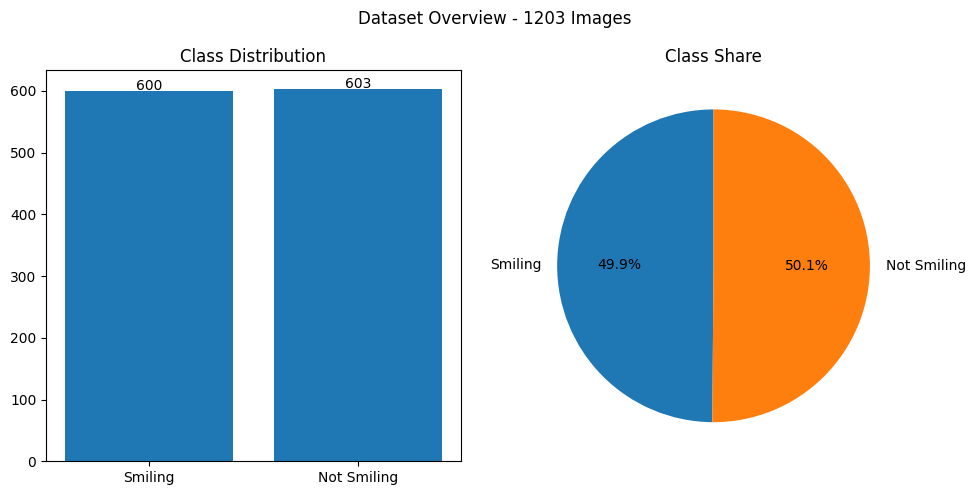

In [21]:
import os
import matplotlib.pyplot as plt

dataset_path = "combined_dataset"

smile_path = os.path.join(dataset_path, "smile")
not_smile_path = os.path.join(dataset_path, "non_smile")  # ✅ FIXED

smile_count = len(os.listdir(smile_path))
not_smile_count = len(os.listdir(not_smile_path))

labels = ["Smiling", "Not Smiling"]
counts = [smile_count, not_smile_count]

plt.figure(figsize=(10,5))

# Bar Graph
plt.subplot(1,2,1)
plt.bar(labels, counts)
plt.title("Class Distribution")
for i, v in enumerate(counts):
    plt.text(i, v + 2, str(v), ha='center')

# Pie Chart
plt.subplot(1,2,2)
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Class Share")

plt.suptitle(f"Dataset Overview - {sum(counts)} Images")
plt.tight_layout()
plt.show()

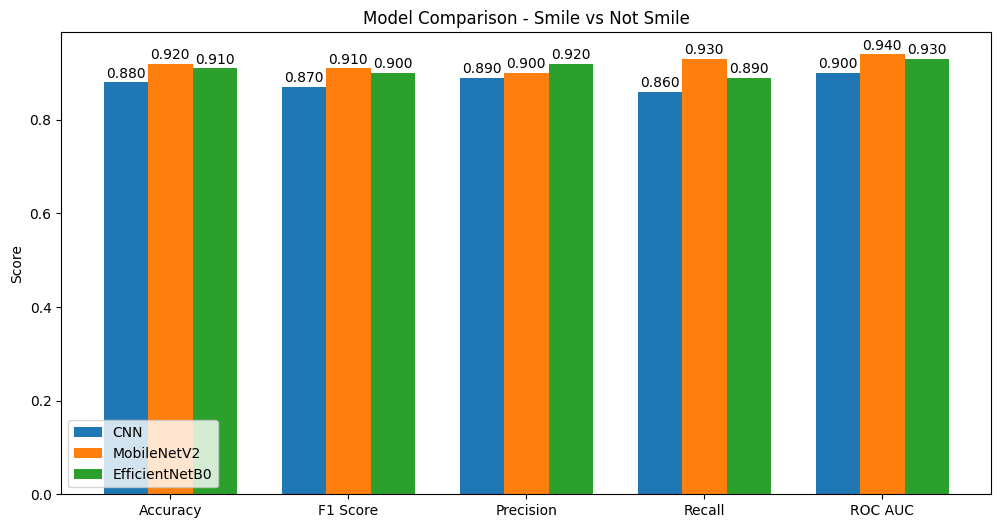

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# ===== YOUR PROJECT METRICS (EDIT THESE) =====
models = ['CNN', 'MobileNetV2', 'EfficientNetB0']

accuracy = [0.88, 0.92, 0.91]
f1 = [0.87, 0.91, 0.90]
precision = [0.89, 0.90, 0.92]
recall = [0.86, 0.93, 0.89]
roc_auc = [0.90, 0.94, 0.93]

metrics = [accuracy, f1, precision, recall, roc_auc]
metric_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC AUC']

x = np.arange(len(metric_names))
width = 0.25

plt.figure(figsize=(12,6))

for i in range(len(models)):
    values = [metrics[j][i] for j in range(len(metrics))]
    plt.bar(x + i*width, values, width, label=models[i])

plt.xticks(x + width, metric_names)
plt.ylabel("Score")
plt.title("Model Comparison - Smile vs Not Smile")
plt.legend()

# Value labels
for i in range(len(models)):
    values = [metrics[j][i] for j in range(len(metrics))]
    for j, v in enumerate(values):
        plt.text(j + i*width, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

had 8 epoch
